In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data

data = load_data("../data/nifty50_processed.csv")
data.head()

,Close,High,Low,Open,Volume,returns,volatility
Date,,,,,,,
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002033,NaN
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.030422,NaN
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003112,NaN
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016221,NaN
2015-01-09,8284.500000,8303.299805,8190.799805,8285.450195,148000,0.006042,NaN


In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['returns'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.624903927228054
p-value: 1.7677609625915691e-25


In [3]:
data = data.dropna()

<Figure size 1200x500 with 0 Axes>

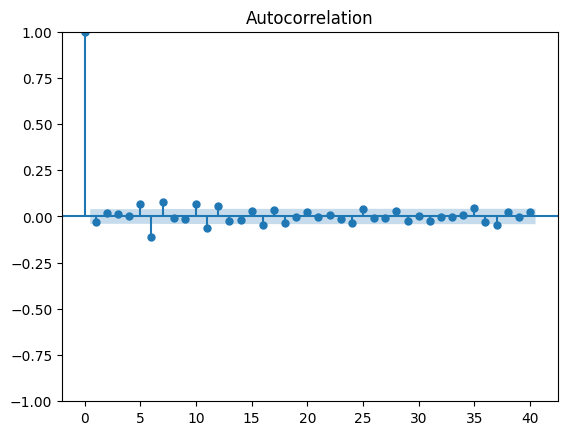

<Figure size 1200x500 with 0 Axes>

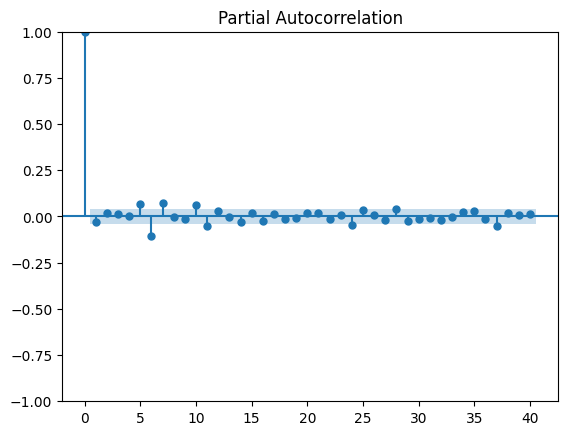

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(data['returns'], lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(data['returns'], lags=40)
plt.show()

In [5]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data['returns'], order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

/Users/divyanshsingh/volatility-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/divyanshsingh/volatility-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/divyanshsingh/volatility-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 2438
Model:                 ARIMA(1, 0, 1)   Log Likelihood                7642.538
Date:                Mon, 23 Mar 2026   AIC                         -15277.077
Time:                        23:05:03   BIC                         -15253.881
Sample:                             0   HQIC                        -15268.645
                               - 2438                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.792      0.073   -3.78e-05       0.001
ar.L1         -0.2514      0.226     -1.111      0.267      -0.695       0.192
ma.L1          0.2214      0.231      0.960      0.3

In [7]:
data['arima_pred'] = model_fit.predict(start=0, end=len(data)-1)

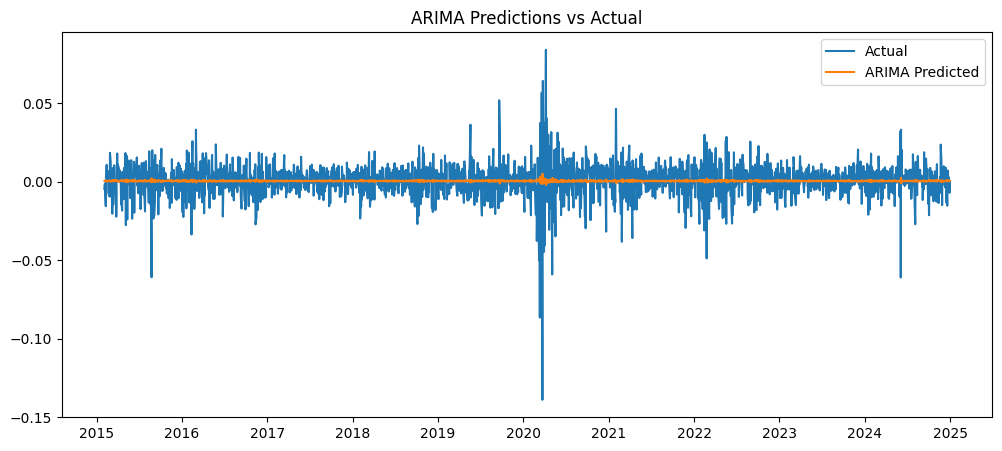

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['returns'], label='Actual')
plt.plot(data['arima_pred'], label='ARIMA Predicted')
plt.legend()
plt.title("ARIMA Predictions vs Actual")
plt.show()

In [9]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(data['returns'], data['arima_pred']))
print("RMSE:", rmse)

RMSE: 0.010528220132171362


In [10]:
data.to_csv("../data/nifty50_with_arima.csv")

In [11]:
data[['returns', 'arima_pred']].to_csv("../results/arima_results.csv")